**Step 1: Load Data**

In [6]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("titanic")

train = pd.read_csv(DATA_PATH / "train.csv")
test = pd.read_csv(DATA_PATH / "test.csv")


**Step 2: Perform Data Analysis**

*First: Perfoming a Data Summary*

In [12]:
#displays top 5 rows of data
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#displays rows, attribute's type, non-null values
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
#display count, mean, std, min/max
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


*Second: Perfoming a Histogram Analysis*

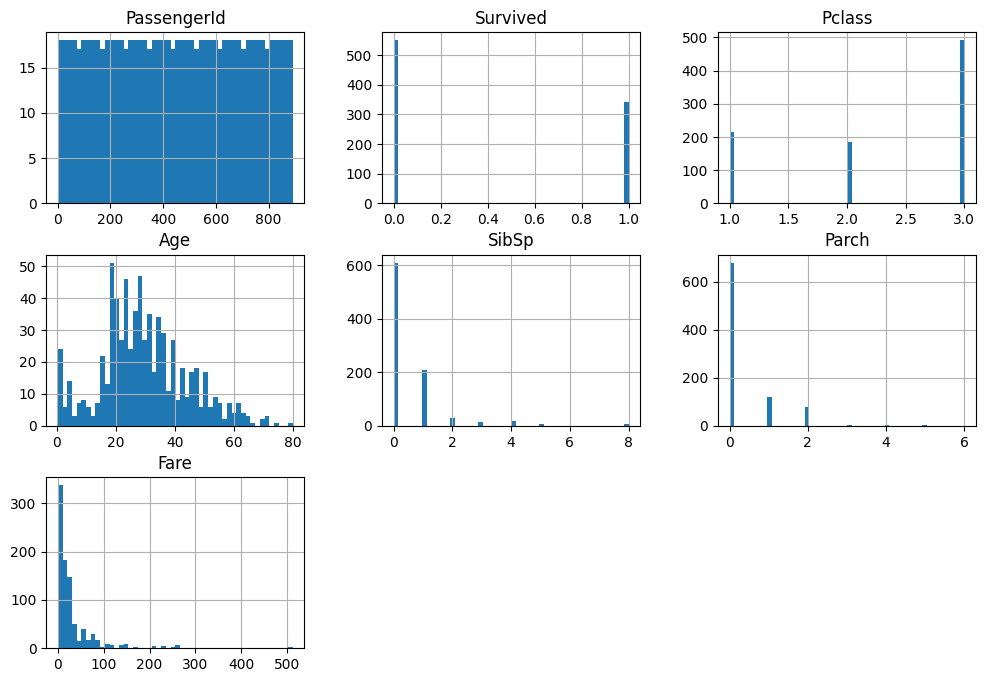

In [ ]:
import matplotlib.pyplot as plt

#histogram for all numeric features
train.hist(bins=50, figsize=(12,8))
plt.show()

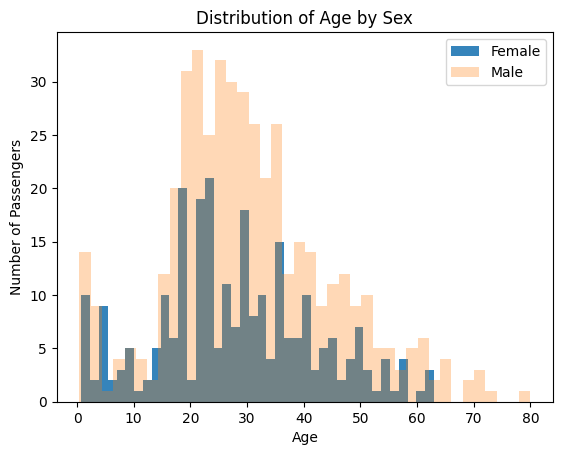

In [35]:
#histogram for sex and age
import matplotlib.pyplot as plt

f_age = train[train["Sex"] == "female"]["Age"]
m_age = train[train["Sex"] == "male"]["Age"]
plt.hist(f_age, label="Female", bins=40, alpha=0.9)
plt.hist(m_age, label="Male", bins=40, alpha=0.3)

plt.title("Distribution of Age by Sex")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

*Third: Performing a Standard Deviation*

In [53]:
train.groupby("Survived")["Age"].std()

Survived
0    14.172110
1    14.950952
Name: Age, dtype: float64

**Step 3: Perform ETL (Extract, Transform, Load)**

Preparing Data for ML Algorithms!!

In [55]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

*Cleaning Data*

In [58]:
#handle missing values
train["Age"].fillna(train["Age"].median())
train["Embarked"].fillna(train["Embarked"].mode()[0])
train.drop(columns=["Cabin"])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


*Handling Categorical Values*

In [59]:
#categorical attributes encoding
train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
train = pd.get_dummies(train, columns=["Embarked"])

*Scaling and Tranforming Features*

In [61]:
#feature scaling
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]

X = train[features]
y = train["Survived"]

std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)

In [62]:
#train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**Step 4: Training Model**

In [63]:
#random forest classifier

forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Step 5: Report Accuracy**

In [80]:
from sklearn.metrics import f1_score, precision_score, recall_score
#predict and probabilities
y_pred_forest = forest_clf.predict(X_test)
y_proba_forest = forest_clf.predict_proba(X_test)

#show first predictions and probabilities
print("First few predictions:\n", y_pred_forest[:10])
print("\nFirst few probabilities:\n", y_proba_forest[:5])


First few predictions:
 [0 0 0 1 0 1 1 0 1 1]

First few probabilities:
 [[0.67       0.33      ]
 [0.93666667 0.06333333]
 [0.8525     0.1475    ]
 [0.04       0.96      ]
 [0.67       0.33      ]]


In [81]:
#evaluate
accuracy = accuracy_score(y_test, y_pred_forest)
f1 = f1_score(y_test, y_pred_forest)
precision = precision_score(y_test, y_pred_forest)
recall = recall_score(y_test, y_pred_forest)

print(f"Evaluation of the Random Forest:")
print(f"accuracy = {accuracy:.2f}")
print(f"f1-score = {f1:.2f}")
print(f"precision = {precision:.2f}")
print(f"recall = {recall:.2f}")

Evaluation of the Random Forest:
accuracy = 0.81
f1-score = 0.76
precision = 0.79
recall = 0.74


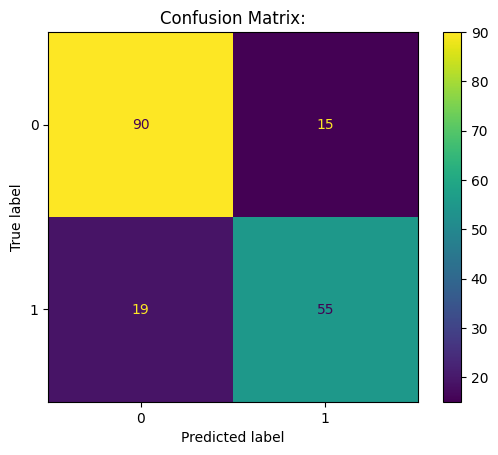

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay
#confusion matrix
ConfusionMatrixDisplay.from_estimator(forest_clf, X_test, y_test)
plt.title("Confusion Matrix:")
plt.show()

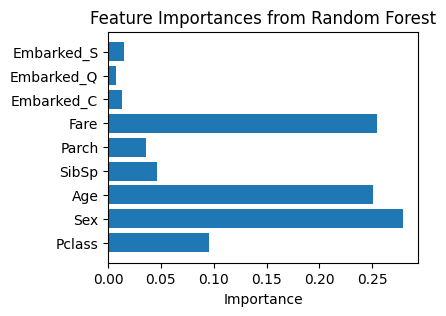

In [85]:
#feature importance
importances = forest_clf.feature_importances_
plt.figure(figsize=(4,3))
plt.title("Feature Importances from Random Forest")
plt.barh(features, importances)
plt.xlabel("Importance")
plt.show()